In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# GENERAMOS DATASET

In [2]:
# Generar datos sintéticos para una serie temporal bivariada
def generate_data(n_samples=1000):
    np.random.seed(42)
    t = np.arange(n_samples)
    var1 = np.sin(0.02 * t) + 0.5 * np.random.randn(n_samples)  # Señal principal
    var2 = np.cos(0.02 * t) + 0.5 * np.random.randn(n_samples)  # Variable secundaria
    return np.column_stack((var1, var2))

# Preparar datos
series = generate_data()
series

array([[ 0.24835708,  1.69967772],
       [-0.04913348,  1.46211685],
       [ 0.3638336 ,  1.02901529],
       ...,
       [ 1.20725364,  0.02115426],
       [ 0.61030657,  0.36273023],
       [ 1.19089296,  0.05380681]])

# ESCALAMIENTO DE DATOS

In [3]:
# Preparar datos
series = generate_data()
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)
series_scaled

array([[0.60242822, 0.82084471],
       [0.5368532 , 0.7714484 ],
       [0.62788238, 0.68139309],
       ...,
       [0.8137951 , 0.47182738],
       [0.68221173, 0.54285167],
       [0.81018876, 0.47861686]])

# CREAMOS SECUENCIAS

In [5]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])  # Predice solo la primera variable
    return np.array(X), np.array(y)

# Definir parámetros
SEQ_LENGTH = 20  # Ventana de tiempo
X, y = create_sequences(series_scaled, SEQ_LENGTH)

In [6]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Construcción del modelo LSTM

In [7]:
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(SEQ_LENGTH, 2)),
    LSTM(50, activation='relu'),
    Dense(25, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.1646 - val_loss: 0.0151
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0151 - val_loss: 0.0131
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0146 - val_loss: 0.0135
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0136 - val_loss: 0.0118
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0144 - val_loss: 0.0131
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0131 - val_loss: 0.0131
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0130 - val_loss: 0.0118
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0128 - val_loss: 0.0118
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0124 - val_loss: 0.0145
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0133 - val_loss: 0.0123
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0130 - val_loss: 0.0118
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0

# Hacer predicciones

In [9]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


# Desnormalizar datos

In [10]:
scaler_y = MinMaxScaler()
scaler_y.fit(series[:, [0]])

MinMaxScaler()

In [11]:
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler_y.inverse_transform(y_pred)

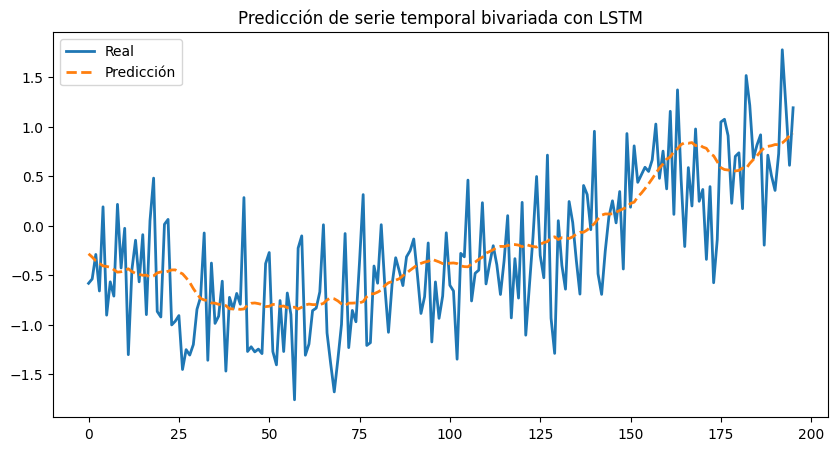

In [12]:
# Graficar predicciones vs valores reales
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Real', linewidth=2)
plt.plot(y_pred_inv, label='Predicción', linestyle='dashed', linewidth=2)
plt.legend()
plt.title("Predicción de serie temporal bivariada con LSTM")
plt.show()